# Rung 4 — Walter learns to pay attention

**The question this notebook answers:** how can a model decide for itself *which* earlier parts of the text matter?

Rung 3's Walter saw exactly 3 letters, through 3 separate slots, each wired to its own weights. That has two problems:

1. **The window is fixed.** Anything 4 letters back is invisible, however important.
2. **Nothing is shared between slots.** An `a` one step back and an `a` two steps back are learned separately, as if they were unrelated facts.

**Attention** fixes both. Every position can look at *every* earlier position, and it decides, based on the content, how much each one matters. The 2017 paper *Attention Is All You Need* (Vaswani et al.) built the transformer around this one operation, and every modern language model descends from it.

We build attention up from the simplest possible idea, averaging, and then train it.

In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

words = open('../data/names.txt').read().splitlines()
chars = sorted(set(''.join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
V = len(stoi)
max_len = max(len(w) for w in words)
block_size = max_len + 1      # '.' + the longest name
print(len(words), 'names, vocabulary', V, ', longest name', max_len, ', so Walter sees up to', block_size, 'positions')

32033 names, vocabulary 27 , longest name 15 , so Walter sees up to 16 positions


## Step 1 — A whole name at once

Until now every training example was one prediction. Now a whole name is one example, and Walter makes a prediction at **every position at the same time**:

```
input :  .  e  m  m  a
target:  e  m  m  a  .
```

At position 3 (the second `m`) Walter is allowed to see `. e m m` and must predict `a`. He must never see the future. Shorter names are padded out to 16 positions, and the padded targets are marked `-1` so the loss ignores them.

We use **exactly the same train/dev/test split as Rung 3** (same shuffle, same seed), and the loss is still the average surprise per predicted character, so the numbers compare directly.

In [2]:
def build_dataset(words):
    X = torch.zeros((len(words), block_size), dtype=torch.long)
    Y = torch.full((len(words), block_size), -1, dtype=torch.long)
    for i, w in enumerate(words):
        ix = [stoi[c] for c in w]
        X[i, 1:len(ix) + 1] = torch.tensor(ix)
        Y[i, :len(ix) + 1] = torch.tensor(ix + [0])
    return X, Y

random.seed(42)
shuffled = words[:]
random.shuffle(shuffled)
n1, n2 = int(0.8 * len(shuffled)), int(0.9 * len(shuffled))
Xtr, Ytr = build_dataset(shuffled[:n1])
Xdev, Ydev = build_dataset(shuffled[n1:n2])
Xte, Yte = build_dataset(shuffled[n2:])
print('train', tuple(Xtr.shape), ' dev', tuple(Xdev.shape))
print('input :', Xtr[0].tolist())
print('target:', Ytr[0].tolist(), ' <- name:', shuffled[0])

train (25626, 16)  dev (3203, 16)
input : [0, 25, 21, 8, 5, 14, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0]
target: [25, 21, 8, 5, 14, 7, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1]  <- name: yuheng


## Step 2 — The simplest way to use the past: average it

Say every position holds a vector (an embedding, as in Rung 3). The crudest way for position `t` to "know about" everything before it is to **average** the vectors at positions `0 … t`.

There's a neat trick for doing every position's average at once: multiply by a lower-triangular matrix whose rows sum to 1. Row `t` has `1/(t+1)` in its first `t+1` slots and zeros after, which is "average of everything so far, and nothing from the future".

In [3]:
T = 5
weights = torch.tril(torch.ones(T, T))
weights = weights / weights.sum(1, keepdim=True)
print(weights)

x = torch.randn(T, 2)          # 5 positions, each a 2-number vector
print('\nby matrix multiply:', (weights @ x)[3])
print('by hand, mean x[0:4]:', x[:4].mean(0))

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])

by matrix multiply: tensor([-0.2755,  0.6078])
by hand, mean x[0:4]: tensor([-0.2755,  0.6078])


## Step 3 — From averaging to *choosing*

Plain averaging treats every earlier letter as equally important, which is obviously wrong. To predict what follows `isabel`, the `l` matters far more than the `i`.

Look at the averaging weights from a different angle. They're what you get by:

1. starting with **scores** of 0 everywhere,
2. setting the future to `−∞` (forbidden),
3. applying **softmax**, the same exp-then-normalise from Rung 2.

With all scores equal, softmax gives a uniform average. **Make the scores unequal and you get a weighted average** that favours some positions over others. That's the whole idea of attention: let the network compute the scores from the data.

In [4]:
scores = torch.zeros(T, T)
mask = torch.tril(torch.ones(T, T)) == 0
print(F.softmax(scores.masked_fill(mask, float('-inf')), dim=1))

scores = torch.tensor([[0., 0, 0, 0, 0],
                       [0., 0, 0, 0, 0],
                       [0., 0, 0, 0, 0],
                       [0., 3, 0, 0, 0],      # position 3 finds position 1 very interesting
                       [0., 0, 0, 0, 0]])
print(F.softmax(scores.masked_fill(mask, float('-inf')), dim=1)[3])

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])
tensor([0.0433, 0.8700, 0.0433, 0.0433, 0.0000])


## Step 4 — Where the scores come from: queries, keys and values

Every position produces three vectors from its own embedding, each through its own learned matrix:

- a **query** `q`: *"what am I looking for?"*
- a **key** `k`: *"what do I contain?"*
- a **value** `v`: *"if you pick me, here's what I'll pass along"*

The score between position `t` (asking) and position `s` (being asked) is the dot product `q_t · k_s`, which is large when the question matches the answer. We divide by `√head_size` so the scores don't grow with the vector size (big scores would make softmax pick one position and ignore the rest). Then mask, softmax, and take the weighted average of the **values**.

$$\text{attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + \text{mask}\right)V$$

That formula is the heart of every transformer. Here it is in code: a single **attention head**.

In [5]:
class Head(nn.Module):
    def __init__(self, n_embd, head_size):
        super().__init__()
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)) == 0)
        self.att = None   # we keep the last attention pattern so we can look at it

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.query(x), self.key(x), self.value(x)            # (B, T, head_size) each
        scores = q @ k.transpose(-2, -1) / k.shape[-1] ** 0.5          # (B, T, T)
        scores = scores.masked_fill(self.mask[:T, :T], float('-inf'))  # no peeking at the future
        att = F.softmax(scores, dim=-1)
        self.att = att.detach()
        return att @ v                                                 # weighted average of values

## Step 5 — Attention can't tell order: positions

There's a catch. Attention is a weighted average, and an average doesn't care about order. Shuffle the earlier letters and, as far as attention can tell, nothing changed. But `ana` and `naa` are very different!

The fix is to give each **position** its own learned embedding too, and add it to the letter's embedding. Now "an `a` at position 2" and "an `a` at position 5" are different vectors, and attention can use where something is as well as what it is.

In [6]:
torch.manual_seed(0)
head = Head(n_embd=8, head_size=8)
emb = torch.randn(V, 8)
a, n = emb[stoi['a']], emb[stoi['n']]
# look at the last position of "naa" vs "ana" (the last letter, 'a', is the same; only the order before it differs)
naa = torch.stack([n, a, a]).unsqueeze(0)
ana = torch.stack([a, n, a]).unsqueeze(0)
print('without positions, same output? ', torch.allclose(head(naa)[0, -1], head(ana)[0, -1]))
pos = torch.randn(3, 8)
print('with positions,    same output? ', torch.allclose(head(naa + pos)[0, -1], head(ana + pos)[0, -1]))

without positions, same output?  True
with positions,    same output?  False


## Step 6 — Walter, with attention

The model is deliberately minimal, so that we can see what attention *alone* buys:

```
letters → letter embedding + position embedding → x
x + attention(x) → linear → 27 logits
```

The `x + …` is a **residual connection**: Walter keeps what he already knew at this position (the current letter and where he is) and *adds* whatever attention gathered from earlier positions. Rung 5 explains why this matters so much.

We train three versions on the same data:

- **no attention**: only the current letter and its position, so a bigram that knows where it is
- **1 head**: one attention head
- **4 heads**: four smaller heads side by side, each free to look for something different (**multi-head attention**)

We also switch optimiser. **Adam** is gradient descent that keeps a running average of each parameter's past gradients, which smooths out mini-batch noise, and gives each parameter its own step size. It's the standard choice for transformers.

In [7]:
class MultiHead(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.heads = nn.ModuleList([Head(n_embd, n_embd // n_head) for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd)    # mixes the heads' findings back together

    def forward(self, x):
        return self.proj(torch.cat([h(x) for h in self.heads], dim=-1))

class AttentionWalter(nn.Module):
    def __init__(self, n_embd=64, n_head=1):
        super().__init__()
        self.tok = nn.Embedding(V, n_embd)
        self.pos = nn.Embedding(block_size, n_embd)
        self.attn = MultiHead(n_embd, n_head) if n_head > 0 else None
        self.out = nn.Linear(n_embd, V)

    def forward(self, idx, targets=None):
        T = idx.shape[1]
        x = self.tok(idx) + self.pos(torch.arange(T))
        if self.attn is not None:
            x = x + self.attn(x)
        logits = self.out(x)
        loss = None if targets is None else F.cross_entropy(logits.view(-1, V), targets.view(-1), ignore_index=-1)
        return logits, loss

def train(model, steps=10_000, batch_size=32, lr=3e-3, seed=2026):
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    for step in range(steps):
        ix = torch.randint(0, len(Xtr), (batch_size,), generator=g)
        _, loss = model(Xtr[ix], Ytr[ix])
        opt.zero_grad()
        loss.backward()
        opt.step()
    return model

@torch.no_grad()
def split_loss(model, X, Y):
    return model(X, Y)[1].item()

results = {}
for name, n_head in [('no attention', 0), ('1 head', 1), ('4 heads', 4)]:
    torch.manual_seed(2026)
    model = train(AttentionWalter(n_head=n_head))
    results[name] = model
    n_params = sum(p.numel() for p in model.parameters())
    print(f'{name:13s} params {n_params:6d}   train {split_loss(model, Xtr, Ytr):.4f}   dev {split_loss(model, Xdev, Ydev):.4f}')

no attention  params   4507   train 2.3110   dev 2.3094


1 head        params  20955   train 2.2046   dev 2.2192


4 heads       params  20955   train 2.1137   dev 2.1467


## Step 7 — Where we stand

In [8]:
print('dev loss, lower is better')
print(f'  uniform guessing          3.2958')
print(f'  Rung 1 bigram             2.4533')
print(f'  Rung 4, no attention      {split_loss(results["no attention"], Xdev, Ydev):.4f}')
print(f'  Rung 4, 1 head            {split_loss(results["1 head"], Xdev, Ydev):.4f}')
print(f'  Rung 4, 4 heads           {split_loss(results["4 heads"], Xdev, Ydev):.4f}')
print(f'  Rung 3 MLP (3 letters)    2.1136')

dev loss, lower is better
  uniform guessing          3.2958
  Rung 1 bigram             2.4533
  Rung 4, no attention      2.3094
  Rung 4, 1 head            2.2192
  Rung 4, 4 heads           2.1467
  Rung 3 MLP (3 letters)    2.1136


Read this table carefully, because it says something important.

- **Knowing the position already helps.** "No attention" beats the plain bigram because Walter knows how far into the name he is, which matters a lot for predicting the end.
- **Attention helps a lot.** Adding a single head is a big drop, and it comes purely from being able to look back.
- **Several heads beat one**, because each can track something different.
- **But attention alone doesn't beat the Rung 3 MLP.** Attention *gathers* information from the past, but after gathering there's only one linear layer to *think* about it. Rung 3 had 200 `tanh` neurons to combine its letters. Attention moves information around; a nonlinear layer is what computes with it. Rung 5 puts the two together and stacks them.

## Step 8 — Watching Walter pay attention

Now we can see something Rung 3 could never show us: **where Walter looks**. Below, each row is a position in the name, the moment Walter predicts the next letter, and each column is a position he can look back at. Dark means heavy attention.

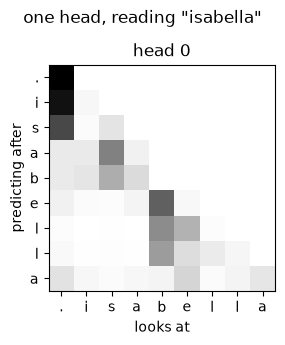

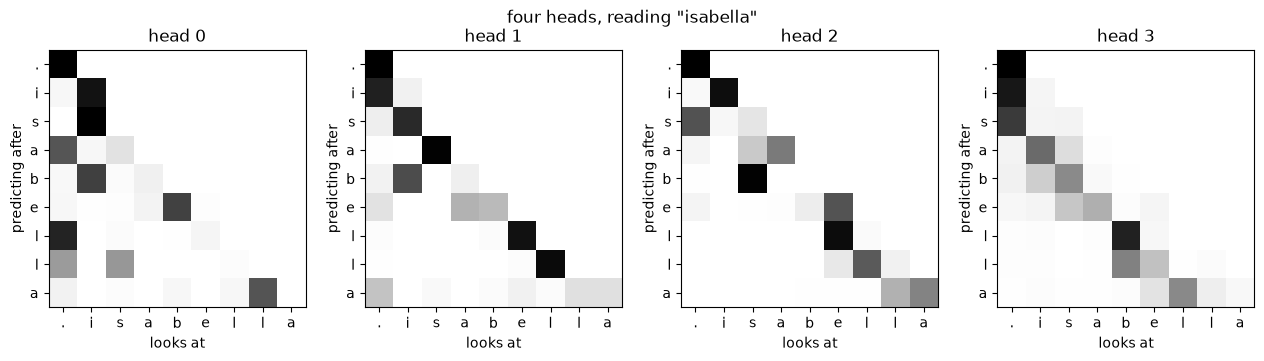

In [9]:
def show_attention(model, name, title):
    x = torch.tensor([[0] + [stoi[c] for c in name]])
    model(x)
    heads = model.attn.heads
    labels = ['.'] + list(name)
    fig, axes = plt.subplots(1, len(heads), figsize=(3.2 * len(heads), 3.4))
    axes = [axes] if len(heads) == 1 else axes
    for h, (ax, head) in enumerate(zip(axes, heads)):
        ax.imshow(head.att[0], cmap='Greys', vmin=0, vmax=1)
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        ax.set_title(f'head {h}')
        ax.set_xlabel('looks at'); ax.set_ylabel('predicting after')
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_attention(results['1 head'], 'isabella', 'one head, reading "isabella"')
show_attention(results['4 heads'], 'isabella', 'four heads, reading "isabella"')

A few things stand out:

- **The patterns are sharp.** Most rows put nearly all their weight on one or two positions. Walter isn't blurring the past together; he's *picking*.
- **Early on, heads lean on the `.` start marker.** With only one or two letters to look at, `.` works as a "nothing interesting yet" default.
- **The four heads don't do the same thing.** In this run, one head mostly looks at the current letter itself (the diagonal), while others jump back to specific earlier letters. That division of labour is why four heads beat one.
- **The single head is more diffuse.** Forced to do everything alone, it spreads its attention, which is a compromise.

Careful, though: this is **one name**. "Head 2 looks back at consonants" might be a real habit or an accident of `isabella`. Telling the difference takes measuring over thousands of names and then *breaking* a head to see what goes wrong. That's Rung 6.

Nobody programmed any of these habits. They're simply the attention patterns that turned out to lower the loss.

## Step 9 — Walter speaks

In [10]:
@torch.no_grad()
def generate(model, n=15, seed=2026):
    g = torch.Generator().manual_seed(seed)
    out = []
    for _ in range(n):
        idx = [0]
        while len(idx) < block_size:
            logits, _ = model(torch.tensor([idx]))
            ix = torch.multinomial(F.softmax(logits[0, -1], dim=-1), 1, generator=g).item()
            if ix == 0:
                break
            idx.append(ix)
        out.append(''.join(itos[i] for i in idx[1:]))
    return out

print('\n'.join(generate(results['4 heads'])))

sorboderh
cabrenn
kency
amvaitea
sonlyna
bina
charia
watne
bryalyn
ozaiah
xiady
edycole
hayna
abilyne
amaliyah


## What just happened

1. **Whole names, every position at once**, and a mask so no position sees the future.
2. **Averaging the past** is a matrix multiply with a lower-triangular matrix.
3. **Softmax over scores** turns averaging into *choosing*, and learned scores make it attention.
4. **Queries, keys and values**: each position asks, advertises, and offers.
5. **Position embeddings**, because attention on its own can't tell order.
6. **The experiment**: attention is a big improvement over the bigram, but alone it gathers without much thinking, and doesn't beat the MLP.

## Your turn (do these before Rung 5)
- Remove the position embedding (`x = self.tok(idx)`) and retrain the 4-head model. How much worse is it, and why?
- Remove the `/ k.shape[-1] ** 0.5` scaling. Print a few attention rows: are they spikier?
- Try 8 heads of size 8, and 2 heads of size 32. Is it the number of heads or their size that matters?
- Pick a long name from the dev set and plot its attention. Which head would you call a "previous letter" head?

**Next — Rung 5:** we add the missing thinking part, an MLP after each attention layer, and then stack several of these blocks, with residual connections and layer normalisation holding the stack together. That's a GPT.